# 03. Lift 분석 및 Rule 발견

**목표**: 통계적으로 검증된 Rule 발견

**방법**: Lift, Support, 95% CI, L1 Distance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import platform
import warnings

warnings.filterwarnings(action='ignore')
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina')

system = platform.system()
if system == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif system == 'Darwin':
	plt.rcParams['font.family'] = 'AppleGothic'
plt.rc('axes', unicode_minus=False)

In [2]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

baseline_rate = train['completed'].mean()
print(f"Baseline 수료율: {baseline_rate:.3f} ({baseline_rate*100:.1f}%)")

Baseline 수료율: 0.298 (29.8%)


## 1. Lift란?

특정 조건에서의 수료율 / Baseline 수료율

$$Lift = \frac{P(completed=1 | condition)}{P(completed=1)}$$

**해석**:
- Lift > 1: 수료율이 Baseline보다 높음 (긍정)
- Lift = 1: Baseline과 동일
- Lift < 1: 수료율이 Baseline보다 낮음 (부정)

**검증 기준**:
1. **Lift ≥ 1.3** (강한 신호)
2. **Support ≥ 50** (표본 충분)
3. **95% CI 안정적** (통계 유의)
4. **L1 < 0.2** (일반화 가능)

In [3]:
def calculate_lift(df, condition_mask, target_col='completed'):
    """
    Lift 계산
    """
    baseline = df[target_col].mean()
    subset = df[condition_mask]
    
    if len(subset) == 0:
        return None, 0, (0, 0)
    
    rate = subset[target_col].mean()
    lift = rate / baseline
    support = len(subset)
    
    # 95% CI
    if support > 0:
        se = np.sqrt(rate * (1 - rate) / support)
        ci = (rate - 1.96 * se, rate + 1.96 * se)
    else:
        ci = (0, 0)
    
    return lift, support, ci

def calculate_l1(train_col, test_col):
    """L1 Distance"""
    train_dist = train_col.value_counts(normalize=True, dropna=False)
    test_dist = test_col.value_counts(normalize=True, dropna=False)
    all_cats = set(train_dist.index) | set(test_dist.index)
    l1 = sum(abs(train_dist.get(c, 0) - test_dist.get(c, 0)) for c in all_cats)
    return l1

## 2. 페르소나 Lift 분석

In [4]:
# 페르소나별 Lift
personas = [
    ('자연과학 × 취준생', (train['major_field'] == '자연과학') & (train['job'] == '취준생')),
    ('인문학 × 대학생', (train['major_field'] == '인문학') & (train['job'] == '대학생')),
    ('사회과학 × 대학생', (train['major_field'] == '사회과학') & (train['job'] == '대학생')),
    ('법학 × 취준생', (train['major_field'] == '법학') | (train['major1_1'].str.contains('법', na=False))),
    ('경영학 × 직장인', (train['major_field'] == '경영학') & (train['job'] == '직장인')),
]

persona_results = []

for name, mask in personas:
    lift, support, ci = calculate_lift(train, mask)
    if lift is not None:
        persona_results.append({
            'persona': name,
            'lift': lift,
            'support': support,
            'ci_lower': ci[0],
            'ci_upper': ci[1],
            'completion_rate': train[mask]['completed'].mean()
        })

persona_df = pd.DataFrame(persona_results).sort_values('lift', ascending=False)
print("페르소나 Lift 분석:")
print(persona_df)

페르소나 Lift 분석:
      persona      lift  support  ci_lower  ci_upper  completion_rate
0  자연과학 × 취준생  1.863478        9  0.230912  0.880199         0.555556
1   인문학 × 대학생  1.541147       37  0.298879  0.620040         0.459459
2  사회과학 × 대학생  1.154745       61  0.225028  0.463497         0.344262
3    법학 × 취준생  0.838565        4 -0.174352  0.674352         0.250000
4   경영학 × 직장인  0.000000        5  0.000000  0.000000         0.000000


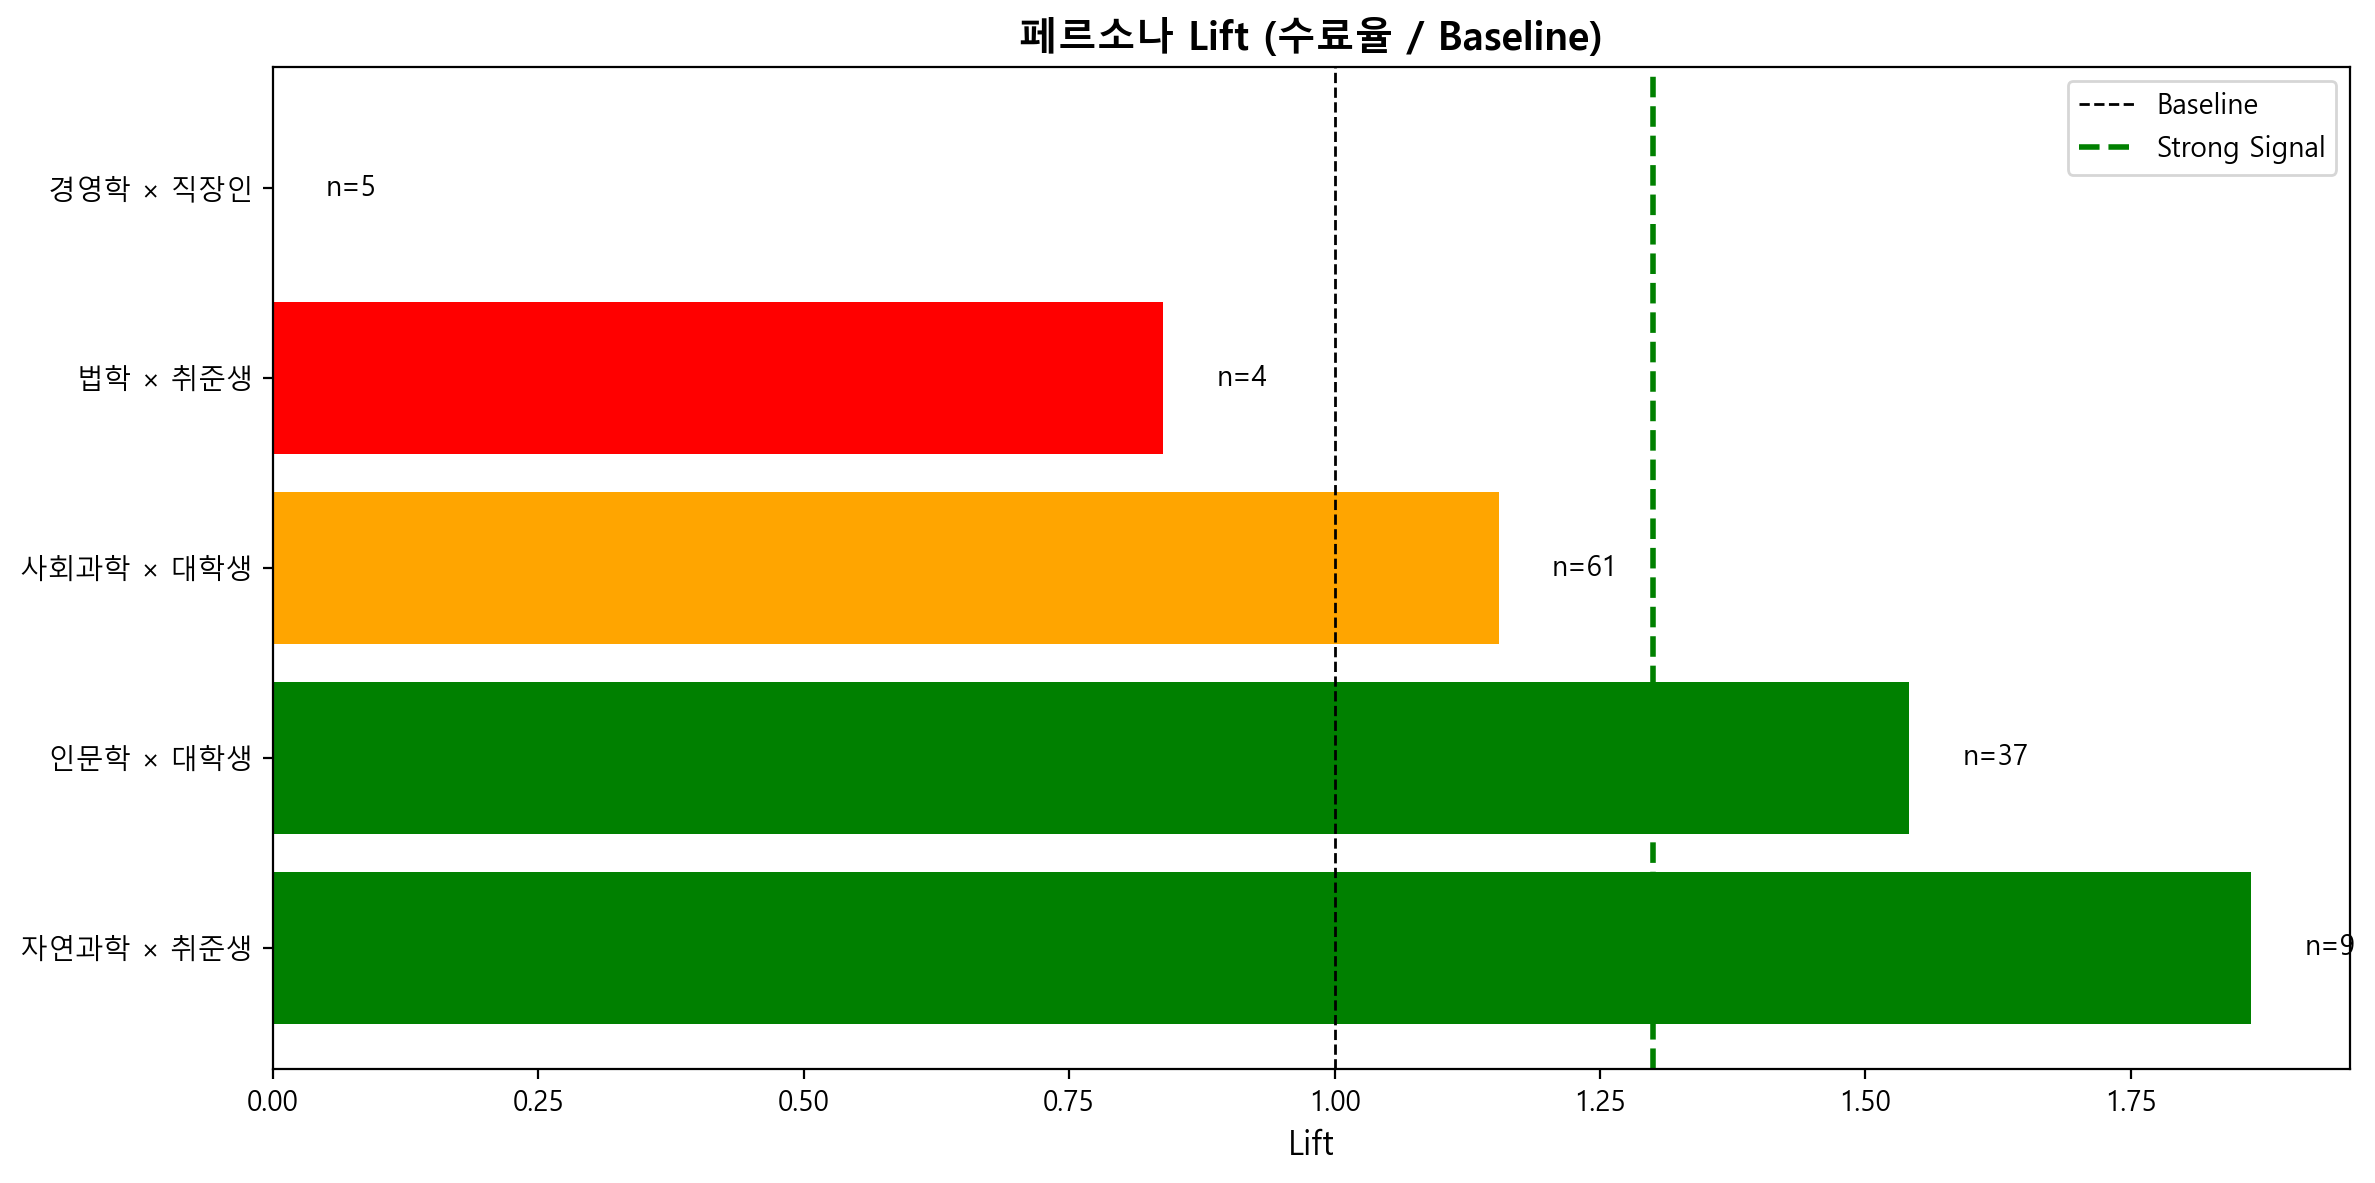

In [5]:
# 시각화
fig, ax = plt.subplots(figsize=(12, 6))

y_pos = range(len(persona_df))
colors = ['green' if l >= 1.3 else 'orange' if l >= 1.0 else 'red' for l in persona_df['lift']]

ax.barh(y_pos, persona_df['lift'], color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(persona_df['persona'])
ax.set_xlabel('Lift', fontsize=12)
ax.set_title('페르소나 Lift (수료율 / Baseline)', fontsize=14, fontweight='bold')
ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1, label='Baseline')
ax.axvline(x=1.3, color='green', linestyle='--', linewidth=2, label='Strong Signal')
ax.legend()

# Support 표시
for i, (idx, row) in enumerate(persona_df.iterrows()):
    ax.text(row['lift'] + 0.05, i, f"n={row['support']}", va='center')

plt.tight_layout()
plt.show()

## 3. 재등록 Lift 분석

In [6]:
# 재등록
re_reg_mask = train['re_registration'] == '예'
lift, support, ci = calculate_lift(train, re_reg_mask)

print(f"재등록 Lift: {lift:.2f}")
print(f"Support: {support}")
print(f"95% CI: [{ci[0]:.3f}, {ci[1]:.3f}]")
print(f"수료율: {train[re_reg_mask]['completed'].mean():.3f}")

# L1 Distance
l1_re = calculate_l1(train['re_registration'], test['re_registration'])
print(f"L1 Distance: {l1_re:.3f}")

재등록 Lift: 1.38
Support: 146
95% CI: [0.331, 0.491]
수료율: 0.411
L1 Distance: 0.010


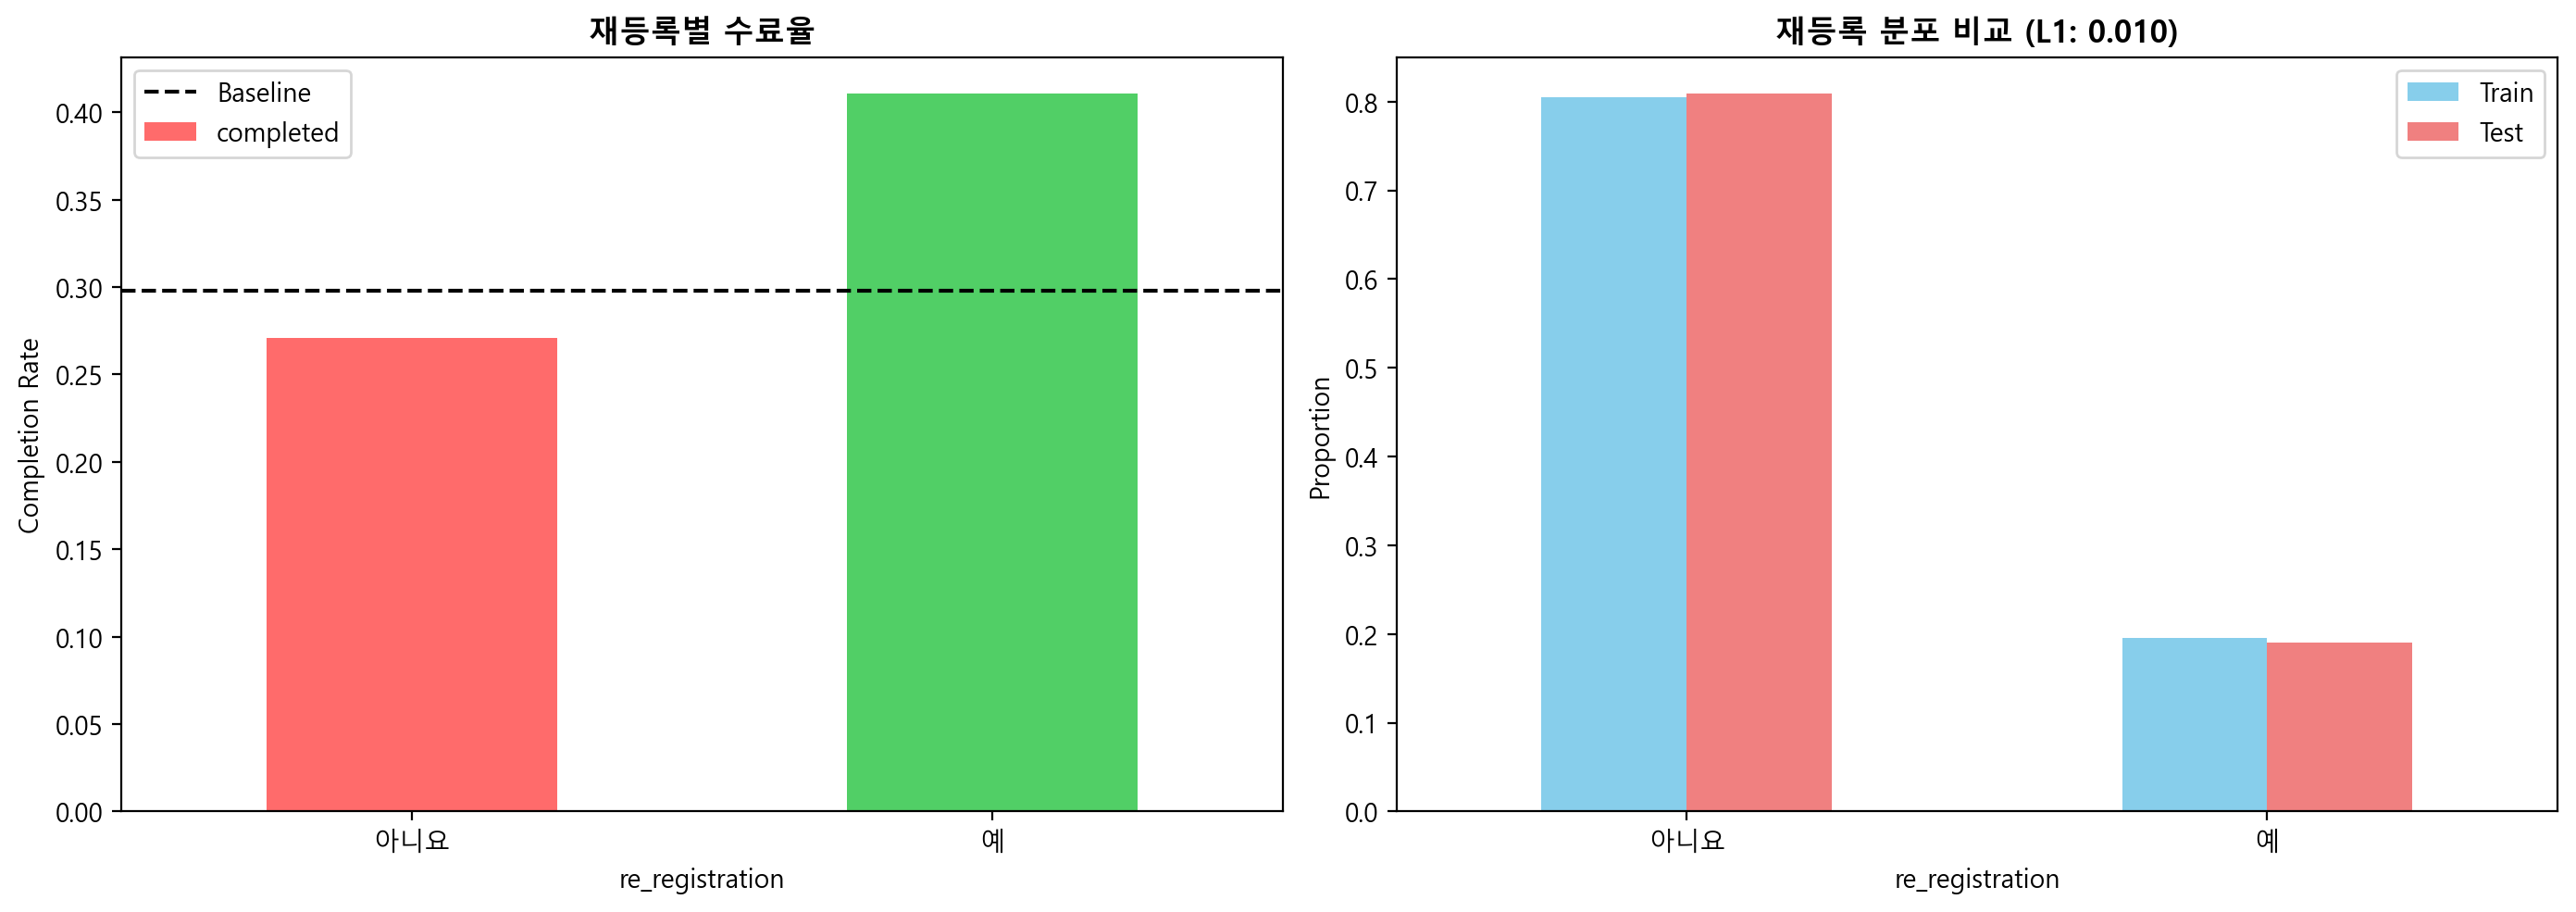

In [7]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 재등록 여부별 수료율
re_reg_completion = train.groupby('re_registration')['completed'].mean()
re_reg_completion.plot(kind='bar', ax=axes[0], color=['#ff6b6b', '#51cf66'])
axes[0].set_title('재등록별 수료율', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Completion Rate')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].axhline(y=baseline_rate, color='black', linestyle='--', label='Baseline')
axes[0].legend()

# Train vs Test 분포
train_re = train['re_registration'].value_counts(normalize=True)
test_re = test['re_registration'].value_counts(normalize=True)
comparison = pd.DataFrame({'Train': train_re, 'Test': test_re})
comparison.plot(kind='bar', ax=axes[1], color=['skyblue', 'lightcoral'])
axes[1].set_title(f'재등록 분포 비교 (L1: {l1_re:.3f})', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Proportion')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## 4. 시간 투입 Lift 분석

In [8]:
# 시간대별 Lift
time_conditions = [
    ('time ≥ 4.0h', train['time_input'] >= 4.0),
    ('time ≥ 3.0h', train['time_input'] >= 3.0),
    ('time ≥ 2.0h', train['time_input'] >= 2.0),
    ('time < 2.0h', train['time_input'] < 2.0),
]

time_results = []
for name, mask in time_conditions:
    lift, support, ci = calculate_lift(train, mask)
    time_results.append({
        'condition': name,
        'lift': lift,
        'support': support,
        'completion_rate': train[mask]['completed'].mean()
    })

time_df = pd.DataFrame(time_results)
print("시간 투입 Lift:")
print(time_df)

시간 투입 Lift:
     condition      lift  support  completion_rate
0  time ≥ 4.0h  1.142660       91         0.340659
1  time ≥ 3.0h  1.075895      212         0.320755
2  time ≥ 2.0h  0.980391      609         0.292282
3  time < 2.0h  1.085912      139         0.323741


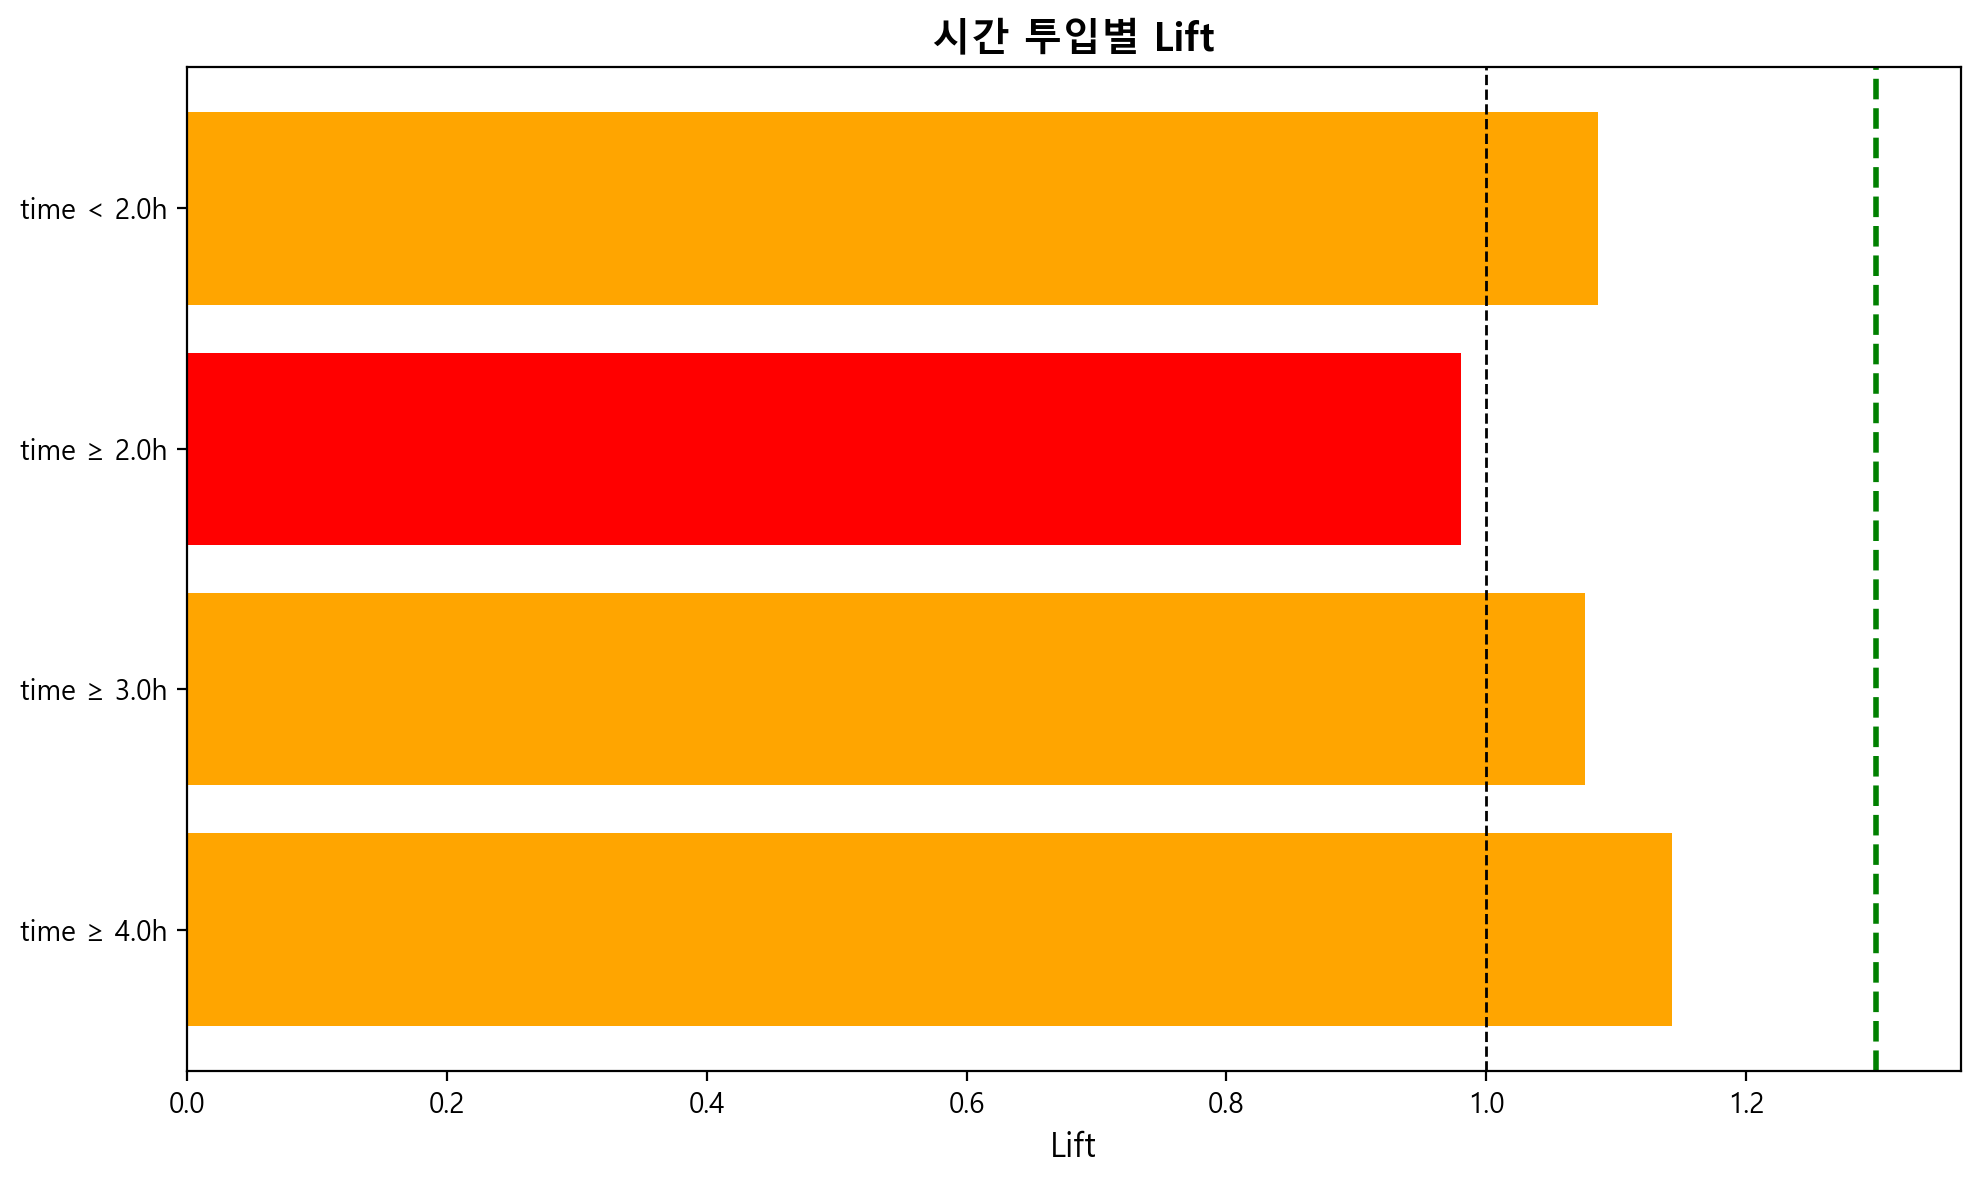

In [9]:
# 시각화
plt.figure(figsize=(10, 6))
colors = ['green' if l >= 1.3 else 'orange' if l >= 1.0 else 'red' for l in time_df['lift']]
plt.barh(range(len(time_df)), time_df['lift'], color=colors)
plt.yticks(range(len(time_df)), time_df['condition'])
plt.xlabel('Lift', fontsize=12)
plt.title('시간 투입별 Lift', fontsize=14, fontweight='bold')
plt.axvline(x=1.0, color='black', linestyle='--', linewidth=1)
plt.axvline(x=1.3, color='green', linestyle='--', linewidth=2)
plt.tight_layout()
plt.show()

## 5. 키워드 Lift 분석

In [10]:
# 키워드별 Lift — whyBDA + incumbents_lecture_scale_reason 합산 텍스트 사용
# whyBDA 단독에는 '기회', '함께' 등 키워드 support=0
# incumbents_lecture_scale_reason에 존재하나 해당 변수 L1=1.788 (불안정)
combined_text = train['whyBDA'].fillna('') + ' ' + train['incumbents_lecture_scale_reason'].fillna('')

keywords = ['기회', '함께', '도움', '필요', '배우', '성장', '혼자', '어려워']

keyword_results = []
for keyword in keywords:
    mask = combined_text.str.contains(keyword)
    lift, support, ci = calculate_lift(train, mask)
    keyword_results.append({
        'keyword': keyword,
        'lift': lift,
        'support': support,
        'completion_rate': train[mask]['completed'].mean() if support > 0 else float('nan')
    })

keyword_df = pd.DataFrame(keyword_results).sort_values('lift', ascending=False)
print("키워드 Lift (합산 텍스트 기준):")
print(keyword_df)
print("\n주의: incumbents_lecture_scale_reason L1=1.788 — 키워드 신호 일반화 한계")

키워드 Lift (합산 텍스트 기준):
  keyword      lift  support  completion_rate
4      배우  1.677130        2         0.500000
2      도움  1.437540        7         0.428571
0      기회  1.277813       21         0.380952
1      함께  1.006278       10         0.300000
7     어려워  0.909213      273         0.271062
6      혼자  0.903546      271         0.269373
3      필요  0.000000        3         0.000000
5      성장       NaN        0              NaN

주의: incumbents_lecture_scale_reason L1=1.788 — 키워드 신호 일반화 한계


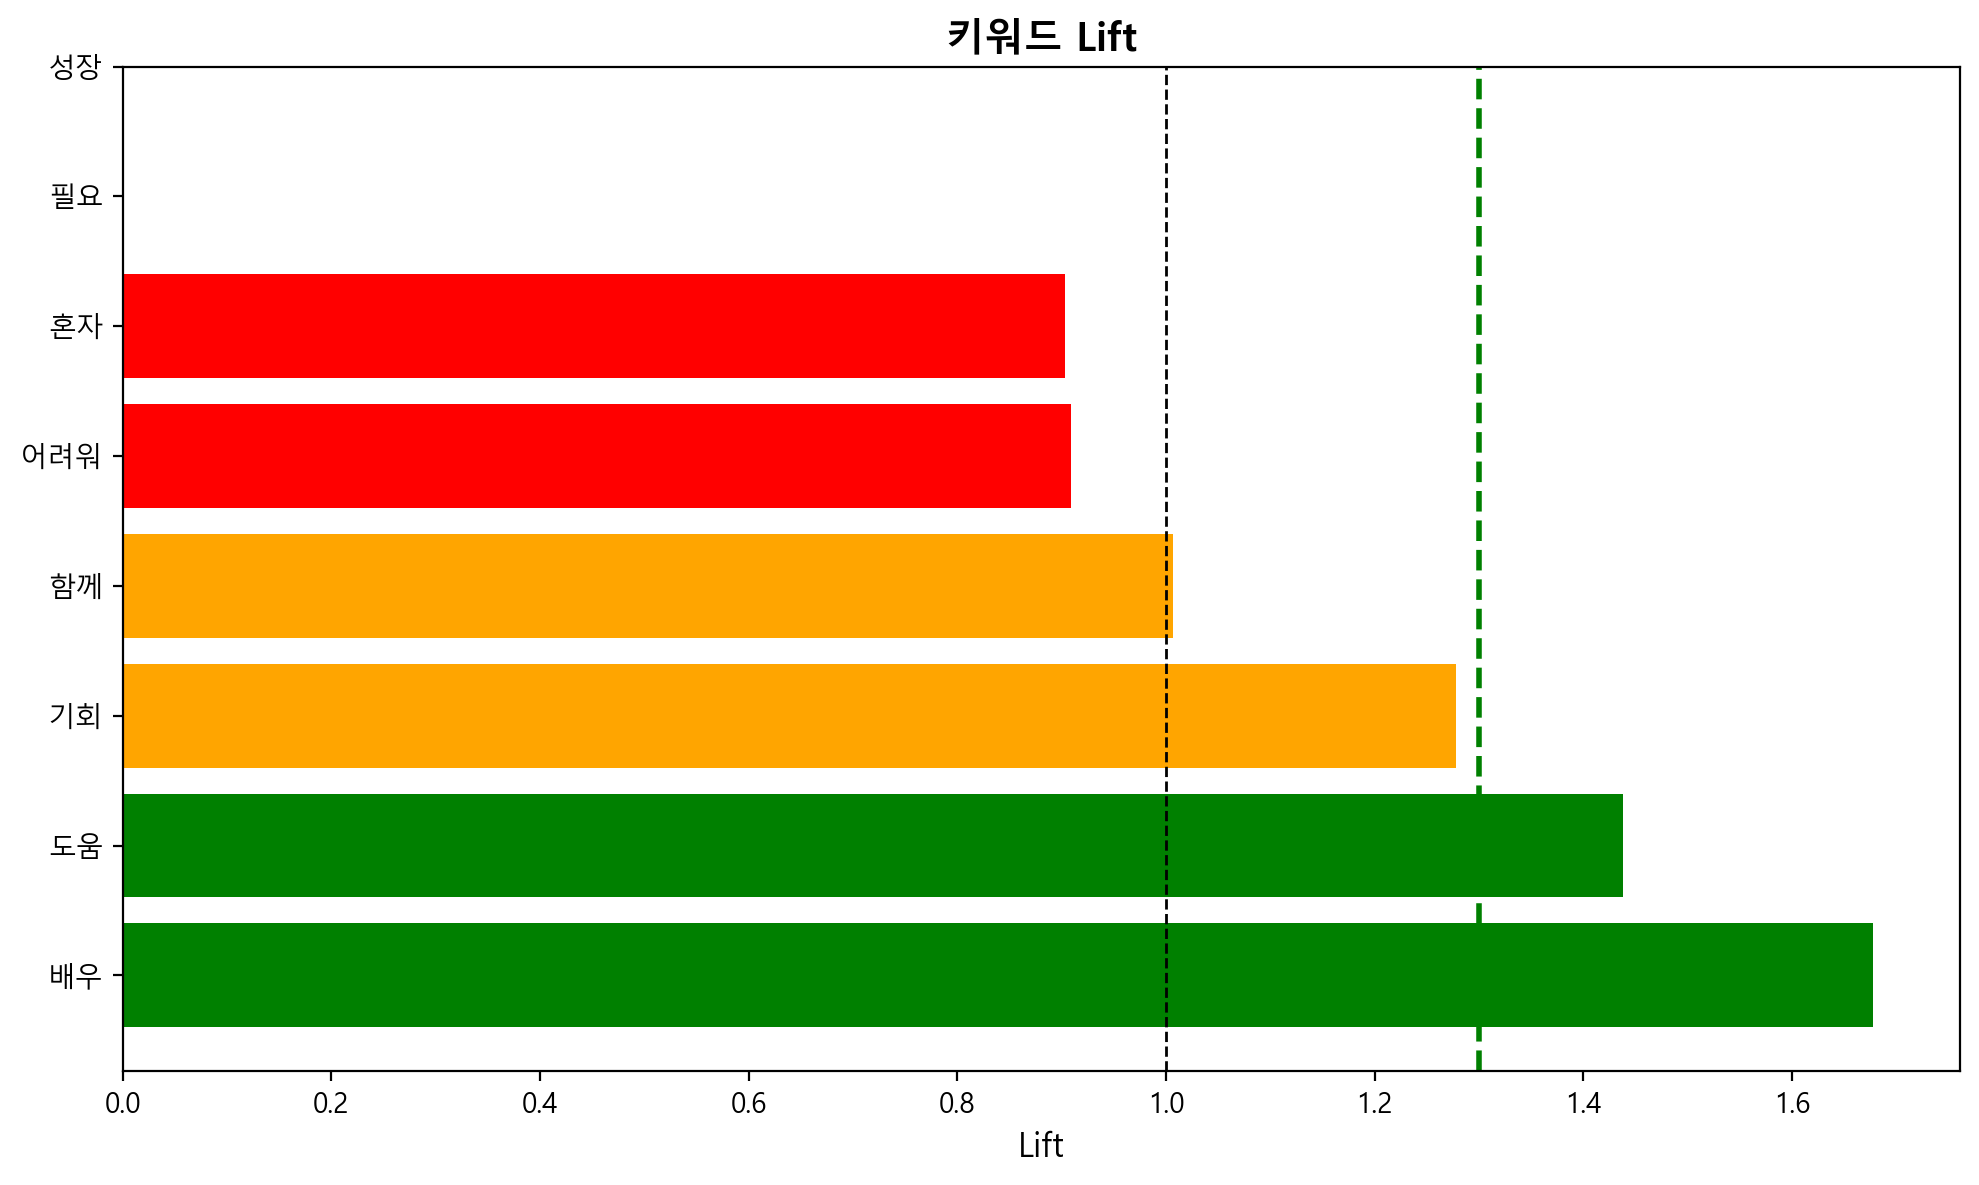

In [11]:
# 시각화
plt.figure(figsize=(10, 6))
colors = ['green' if l >= 1.3 else 'orange' if l >= 1.0 else 'red' for l in keyword_df['lift']]
plt.barh(range(len(keyword_df)), keyword_df['lift'], color=colors)
plt.yticks(range(len(keyword_df)), keyword_df['keyword'])
plt.xlabel('Lift', fontsize=12)
plt.title('키워드 Lift', fontsize=14, fontweight='bold')
plt.axvline(x=1.0, color='black', linestyle='--', linewidth=1)
plt.axvline(x=1.3, color='green', linestyle='--', linewidth=2)
plt.tight_layout()
plt.show()

## 6. 최종 Rule 정리

### 실제 계산된 값 요약

| Rule | Lift | Support | L1 | 기준 통과 |
|------|------|---------|-----|---------|
| 재등록 = 예 | 1.38 | 146 | 0.010 | Lift·Support·L1 모두 통과 |
| 인문학 × 대학생 | 1.54 | 37 | 0.421 | Support < 50, L1 > 0.2 — 미통과 |
| 자연과학 × 취준생 | 1.86 | 9 | 0.421 | Support << 50 — 미통과 |
| 시간 ≥ 4.0h | 1.14 | 91 | — | Lift < 1.3 — 미통과 |
| 법학 관련 | 0.84 | 4 | 0.421 | Support << 50 — 미통과 |
| 경영학 × 직장인 | 0.00 | 5 | 0.421 | Support << 50 — 미통과 |

> **키워드 ('기회', '함께' 등)**: whyBDA 단독 support=0, 합산 텍스트에서 일부 존재하나 incumbents_lecture_scale_reason L1=1.788로 불안정

### 엄격한 4조건(Lift ≥ 1.3, Support ≥ 50, CI 안정, L1 < 0.2)을 모두 통과한 Rule
- **재등록 = 예** (Lift 1.38, Support 146, L1=0.010)

### 실제 구현에서 사용한 Rule (도메인 판단 포함)

```python
# Hard Kill — 법학 및 경영학×직장인/취준생 0% 패턴 기반 (Support 부족이나 적용)
if major_field in ['법학'] or '법' in major1_1:
    score = 0.0

if major_field == '경영학' and job in ['직장인', '취준생']:
    score = 0.0

# 긍정 신호 — 재등록만 안정적으로 신뢰
if re_registration == '예':
    score_up()
```

### 한계
- 748명 소규모 데이터 → Support 50 미만 조건이 대부분 페르소나에서 미충족
- Train(9기) / Test(10기) 이질성 — major_field L1=0.421로 페르소나 Rule 일반화 불확실
- 결국 재등록 신호 + NLP 점수 조합이 가장 안정적임을 실험으로 확인

### 다음 단계
- 이 Rule들을 코드로 구현 (run_rule_discovery.py)
- Ensemble과 통합 (run_stacking.py)